## Formatting for Plots
### (IGNORE THIS IF YOU ARE A GENERAL USER)

In [2]:
import sys
import pandas as pd
from pathlib import Path
root = Path().resolve()
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from analysislib import formatting
from analysislib import graphs
formatting.format_notebook()

from analysislib import sdss
sdss.setup(pd.read_csv("data/SDSS_500k_v7.csv"))

---

## Part 3 — Shape, Size, and Structure

---

<div style="width: 1200px">

In Part 2, we discovered that galaxies split into two distinct colour populations: a blue, star-forming cloud and a red, quenched sequence, with surprisingly few galaxies in between. Just colour tells us quite a bit about a galaxy's evolutionary state. But it raises an immediate question:

<br>

<center>
<span style="
border: 2px solid #DDDDDD;
padding: 10px;
font-size: 25px;
font-style: italic;">
"Does a galaxy's shape also tell us about a galaxy's evolutionary state?"</span>
</center>

<br>

Intuitively, we might expect that blue star-forming galaxies look different from red quenched ones. And indeed they do:

* Spiral galaxies are the most distinctive, and they're kind you've probably seen the most of. These tend to be bluer

* On the other hand, elliptical galaxies are smooth and featureless, and tend to be red.

* However, this relationship is not perfect, and there are certainly quite a few exceptions which are pretty scientifically interesting.

In this notebook, we'll start to explore the **structure** of galaxies, including how spread out the light is, how centrally concentrated the galaxy is, and how these properties relate to evolutionary state.

</div>

---

### Galaxy Morphology and the Hubble Tuning Fork

---


<div style="width: 1200px">

If we're going to analyse the structures of galaxies, we need to begin with understanding how galaxies are classified. The systematic classification of galaxy shapes began in the 1920s with Edwin Hubble, who organised different galaxy types and forms into the **Hubble Tuning Fork**, which is one of the most iconic diagrams in astronomy.

The diagram arranges galaxies along two axes:

* **Left -> right:** As you move along from left to right, galaxies change from smooth, featureless ellipticals to disc-dominated spirals with open, patchy arms. Also, the bulges shrink, the disc grows, and star formation increases a lot.
* **The fork split:** Then, as per the name, the Hubble tuning fork separates normal spirals (which are found in the top arm), from barred spirals (on the bottom arm). These barred spiral galaxies feature a straight stellar bar through the centre from which the arms emerge. About half of all disc galaxies, including the Milky Way, are barred.

The different classes also have special names:

| **Class** | **Name** | **Key features** |
|-------|------|--------------|
| E0–E7 | Ellipticals | These galaxies are smooth, and, based on the number, are in between round and elongated, with no disc or arms. In elliptical galaxies, there are mostly old red stars, and there's essentially no star formation. |
| S0 | Lenticular | Lenticular galaxies are a weird intermediate galaxies, and they usually have a disc but no spiral arms. They have a reasonable amount of star formation and are the bridge between ellipticals and spirals. |
| Sa -> Sc | Spirals | Spiral galaxies have a prominent disc structure with arms. As you increase from Sa to Sc, the galaxy's bulge shrinks and the arms open. These galaxies have very high amounts of star formation and tend to have mostly young blue stars. |
| SBa -> SBc | Barred spirals | Barred spirals are very similar to spiral galaxies, but also have a central stellar bar. They also have different types based on the amount of bulge and the types of spiral arms. |

<br>

> **A common misconception:**

> Hubble called elliptical galaxies "early-type" and spirals "late-type", implying that galaxies evolve from left to right. We now know this is wrong, and if anything, spirals tend to turn *into* ellipticals over time, not the reverse. The "early/late" labels have unfortunately stuck in the literature, but keep in mind that it doesn't correlate to the galaxy's age.

The interactive diagram below allows you to explore the full tuning fork. You can click any class to see its main features and some measurements that we're going to use throughout this section:

</div>

In [3]:
from IPython.display import HTML # Import HTML for display

HTML(graphs.hubble_fork()) # Display the Hubble fork diagram

<div style="width: 1200px">

<center>
<i>Credit: NASA, ESA, Göran Nilsson</i>
<center>

</div>

---

<br>

<div style="width: 1200px">

Now there's just one more morphological type worth knowing: **irregular galaxies** (Irr).

Irregulars don't fit the tuning fork at all. They are chaotic, asymmetric, and intensely star-forming, such as the Large and Small Magellanic Clouds. At higher redshifts, irregular morphologies become much more common, reflecting the pretty violent early universe.

</div>

---

### The Petrosian Radius

---

<div style="width: 1200px">

Okay great! So now that we know the different types of galaxies, another fundamental part of structure is **size**.

However, measuring the size of a galaxy is harder than it sounds. Unlike a ball with a clear edge, galaxies fade into the background and there's no sharp boundary where a galaxy ends and empty space begins. So, we need a robust, distance-independent way to define "how big" a galaxy is.

The solution that the SDSS uses is called the **Petrosian radius**, and the idea is pretty elegant. Rather than asking "where does the galaxy end?", we ask:

"At what radius does the galaxy's surface brightness drop to a fixed fraction of the average brightness inside that radius?"

Okay that might sound a bit convoluted but all it says is:


<div style="width: 250px;
            display: inline-block;
            margin-right: 50px">

<img src="images/annulus.webp"></img>
<center>
<i>Credit: Geeks for Geeks</i>
</center>

</div>

<div style="width: 850px;
            display: inline-block">

Step 1. Choose a radius which we will call $r$, and make a circle of radius $r$ to "sit on top of the galaxy".

Step 2. Calculate the average brightness of everything inside that radius $r$ circle.

Step 3. Make a thick-ish ring around $r$ (called an *annulus*) and calculate the average brightness inside that ring.*

Step 4. Calculate the ratio between the edge brightness and the inside brightness: $\text{ratio} = \frac{\text{edge brightness}}{\text{inside brightness}}$

Step 5. When $ratio = \eta$, where $\eta$ is just some number that we choose (typically 0.2), then that $r$ is the Petrosian radius.

<br>

</div>

<br>

<br>

<div style="width: 750px;
            display: inline-block;
            margin-right: 50px">

I hope you understood that, but if you didn't, that's totally okay, and you can just think of the Petrosian radius as the size of the galaxy.

<br>

But why does this even matter? Why couldn't we have a simpler definition? Well, we definitely could have made it a lot simpler, but the special thing about the Petrosian radius is that it is **independent of distance**, so a galaxy at $z = 0.05$ and the same galaxy at $z = 0.15$ will give the same Petrosian radius in physical units (probably **kiloparsecs****), even though the more distant one appears smaller on the sky. This makes it ideal for comparing galaxy sizes in the SDSS, where we have galaxies at different distances.

In our dataset, this Petrosian radius is stored as `petroRad_r`, and is measured in the $r$ band, in arcseconds (1 arcsecond is 1/3600 of a degree). However, this angle only gives us apparent size, and we'll need to convert it to physical units later on (like the previously mentioned kiloparsec).

</div>

<div style="width: 400px;
            display: inline-block">
<img src="images/petrosian_r.jpg"></img>
<center>
<i>Credit: Michael Richmond</i>
</center>
</div>

<div style="width: 1200px">

We also have access to something called **Petrosian flux**, which is basically how bright the galaxy is. It's calculated by multiplying the total brightness or flux inside the Petrosian radius by some number, which is typically something like 2 or 2.5. Now this is pretty useful, but its even more usable if its in a format called `petroMag_r`, or Petrosian magnitude. The Petrosian magnitude is essentially a logarithmic version of the Petrosian flux, which more accurately reprents how we humans see light, and lets us compare brightness with external sources more easily.

Two other size measurements also appear in the data:

* **`petroR50`**: the radius enclosing 50% of the total Petrosian flux
* **`petroR90`**: the radius enclosing 90% of the total Petrosian flux

<br><br>

**For those of you who are extra curious, this annulus is defined to have its edges at 80% of the radius and 125% of the radius. So, for example, if our radius was 5, then the annulus would be the region in between a circle of radius 4 and a circle of radius 6.25.*

***A kiloparsec is a unit of distance equal to about 30 million billion kilometres, or the distance that light travels in 3,260 years*

</div>

---

### The Concentration Index

---


<div style="width: 1200px">

Now the size of a galaxy is helpful and all, but knowing *where* the light is distributed tells us something a lot more interesting about its structure.

The **concentration index** $C$ captures this:

$$C = 5 \times \log_{10}\left(\frac{r_{90}}{r_{50}}\right)$$

where $r_{90}$ is the radius containing 90% of the light and $r_{50}$ is the radius containing 50% of the light. A galaxy where the light is tightly packed into the centre has a large $r_{90}/r_{50}$ ratio — most of the light is already captured within $r_{50}$, so you need to go much further out to get the remaining 40%. A galaxy where the light is spread smoothly across the disc has a smaller ratio.

In practice:

* **$C \gtrsim 3.0$** — highly concentrated, bulge-dominated: **elliptical galaxies**
* **$C \approx 2.3$–$3.0$** — intermediate concentration: **lenticular (S0) galaxies**  
* **$C \lesssim 2.3$** — diffuse, disc-dominated: **spiral galaxies**

This single number gives us a morphological classification without ever looking at a galaxy image.

</div>

<div style="width: 1200px">

The concentration index also connects directly to the **Sérsic index** $n$, which describes the *shape* of the brightness profile — how quickly light fades outward from the centre:

$$I(r) \propto \exp\left[-b_n\left(\left(\frac{r}{r_e}\right)^{1/n} - 1\right)\right]$$

* **$n = 1$** (exponential) → spiral disc: light fades smoothly and steadily
* **$n = 4$** (de Vaucouleurs) → elliptical: bright compact core with slowly fading wings

The SDSS column `fracDeV_r` is our Sérsic proxy — it records what fraction of the light is better described by the $n=4$ de Vaucouleurs profile vs the $n=1$ exponential. Values near `1.0` mean elliptical-like; near `0.0` mean disc-like.

</div>

---

### Setting Up

---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from IPython.display import display, HTML

display(HTML("""
<style>
  .widget-label { color: #cccccc !important; font-family: monospace !important; }
  .jupyter-widgets { background: transparent !important; }
</style>
"""))

galaxies = sdss._galaxies().copy()

# Derived columns
galaxies["g_r"] = galaxies["g"] - galaxies["r"]
galaxies["C"]   = 5 * np.log10(galaxies["petroR90_r"] / galaxies["petroR50_r"])

# Trim to physically sensible ranges
galaxies = galaxies[(galaxies["g_r"] > -0.2) & (galaxies["g_r"] < 1.4) &(galaxies["petroRad_r"] < 200)].copy()

# z < 0.045 subset for colour-reliable plots
gal_lowz = galaxies[galaxies["redshift"] < 0.045].copy()

# Colour classes based on g-r
# Using peak positions from Part 2: blue cloud < 0.58, red sequence > 0.76
gal_lowz["colour_class"] = pd.cut(
    gal_lowz["g_r"],
    bins=[-np.inf, 0.58, 0.76, np.inf],
    labels=["Blue Cloud", "Green Valley", "Red Sequence"]
)

blue = gal_lowz[gal_lowz["colour_class"] == "Blue Cloud"]
green = gal_lowz[gal_lowz["colour_class"] == "Green Valley"]
red  = gal_lowz[gal_lowz["colour_class"] == "Red Sequence"]

/usr/local/python/3.12.1/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


---

### Plot 1 — Concentration Index by Colour Class

---

<div style="width: 1200px">

If galaxy colour and morphology are genuinely linked — as we expect from decades of visual classification studies — then blue and red galaxies should have systematically different concentration indices. Let's check.

</div>

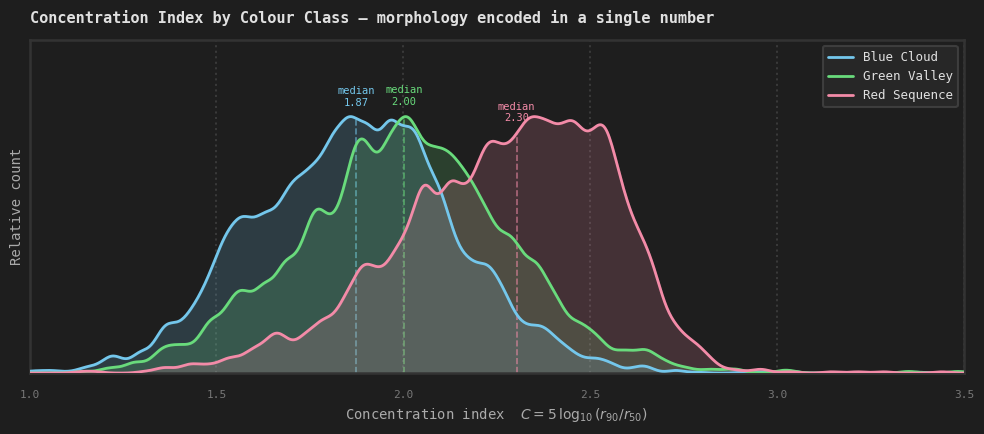

In [5]:
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

x_range = np.linspace(1, 3.5, 800)

populations = [
    (blue,  "#74c7ec", "Blue Cloud"),
    (green, "#69db7c", "Green Valley"),
    (red,   "#f38ba8", "Red Sequence"),
]

for pop, color, label in populations:
    c_vals = pop["C"].dropna().values
    if len(c_vals) < 50:
        continue
    kde = gaussian_kde(c_vals, bw_method=0.08)
    kde_vals = kde(x_range)
    kde_vals = kde_vals / kde_vals.max()
    ax.fill_between(x_range, 0, kde_vals, color=color, alpha=0.18, zorder=2)
    ax.plot(x_range, kde_vals, lw=2, color=color, label=label, zorder=3)
    # Mark the median
    med = np.median(c_vals)
    med_h = kde([med])[0] / kde(x_range).max()
    ax.vlines(med, 0, med_h, color=color, lw=1.2, linestyle="--", alpha=0.6)
    ax.text(med, med_h + 0.04, f"median\n{med:.2f}",
            color=color, fontsize=7.5, ha="center", va="bottom")

# Final plot formatting
ax.set_xlim(1, 3.5)
ax.set_ylim(0, 1.3)
ax.set_yticks([])
ax.set_xlabel(r"Concentration index  $C = 5\,\log_{10}(r_{90}/r_{50})$",
              color="#aaaaaa", fontsize=10)
ax.set_ylabel("Relative count", color="#aaaaaa", fontsize=10)
ax.set_title("Concentration Index by Colour Class — morphology encoded in a single number",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.12, color="#ffffff")
ax.legend(facecolor="#2a2a2a", edgecolor="#444444",
          labelcolor="#e0e0e0", fontsize=9)
for spine in ax.spines.values(): spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

The separation is clear and physically interpretable:

* **Blue Cloud galaxies** peak at lower $C$ — their light is spread across an extended disc, consistent with spiral morphology. The concentration distribution is broad, reflecting the variety of spiral types from loose, open-armed galaxies to tighter, bulge-heavy ones.

* **Red Sequence galaxies** peak at significantly higher $C$ — their light is tightly concentrated toward the centre, the hallmark of elliptical galaxies that have used up or expelled their gas and settled into a smooth, compact structure.

* **Green Valley galaxies** sit in between, with a broad distribution spanning both morphological types. This is consistent with the idea that these are transitioning galaxies — some may have already developed a dominant bulge while still retaining some disc structure; others may be discs whose star formation is being quenched without a major structural transformation.

The dashed reference lines at $C = 2.3$ and $C = 3.0$ mark the conventional boundaries between spiral, lenticular, and elliptical morphologies.

</div>

---

### Plot 2 — The Four Quadrants: Concentration vs Colour

---

<div style="width: 1200px">

The concentration distribution tells us that colour and morphology are correlated — but how tight is that relationship, and what do the outliers look like?

Plotting concentration against $g - r$ colour directly creates a 2D map with four naturally defined quadrants, each telling a different physical story:

| Quadrant | Colour | Concentration | Interpretation |
|----------|--------|---------------|----------------|
| Bottom-left | Blue | Low | Classic **spiral galaxies** — disc-dominated, actively star-forming |
| Top-right | Red | High | Classic **elliptical galaxies** — bulge-dominated, quenched |
| Top-left | Blue | High | **Compact star-forming galaxies** — rare, possibly post-merger starbursts |
| Bottom-right | Red | Low | **Passive disc galaxies** (S0/lenticulars) — quenched but disc structure retained |

The top-left and bottom-right quadrants are the most scientifically interesting: they represent galaxies where colour and morphology have decoupled, hinting at different quenching pathways.

</div>

/tmp/ipykernel_12060/3438198066.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


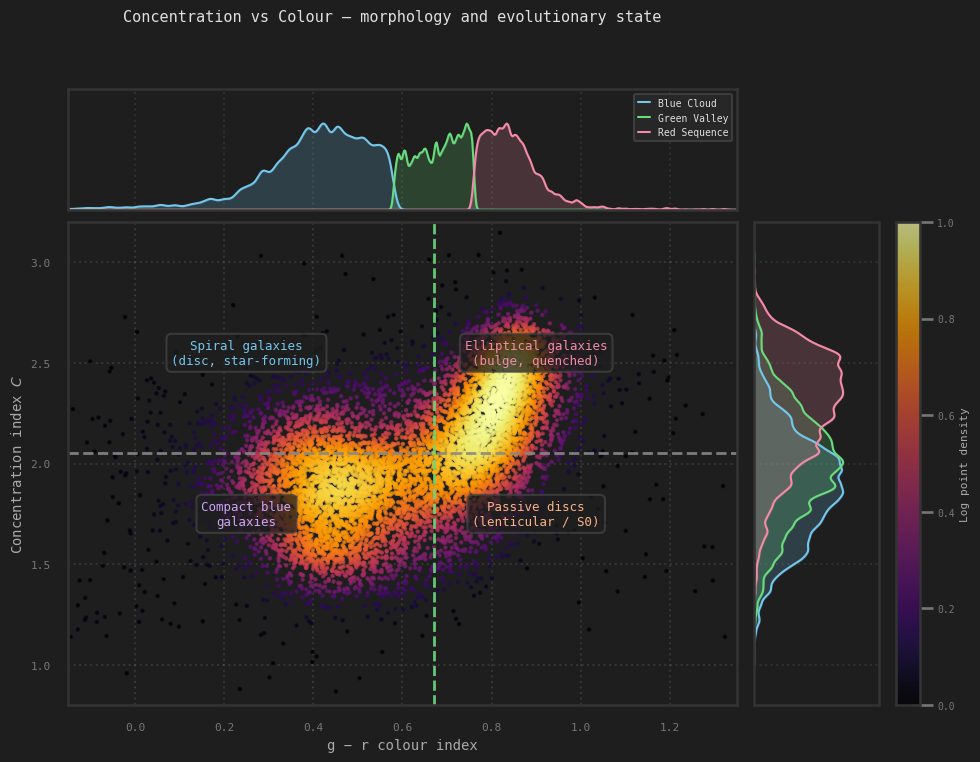

In [6]:
sample = gal_lowz.sample(min(30000, len(gal_lowz)), random_state=67)

x = sample["g_r"].values
y = sample["C"].values

xy = np.vstack([x, y])
density = gaussian_kde(xy)(xy)
sort_idx = density.argsort()
x, y, density = x[sort_idx], y[sort_idx], density[sort_idx]
log_density = np.log1p(density)
log_density = (log_density - log_density.min()) / (log_density.max() - log_density.min())

# Quadrant boundaries
c_split  = 2.05   # concentration boundary
gr_split = 0.67   # colour boundary (green valley centre)

fig = plt.figure(figsize=(11, 8), facecolor="#1e1e1e")
gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], hspace=0.04, wspace=0.04)
ax_main  = fig.add_subplot(gs[1, 0])
ax_top   = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

for ax in [ax_main, ax_top, ax_right]:
    ax.set_facecolor("#1e1e1e")

sc = ax_main.scatter(x, y, c=log_density, s=3, alpha=0.7, cmap="inferno", rasterized=True)

label_props = dict(fontsize=9, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.4", fc="#1e1e1e", ec="#444444", alpha=0.80))

# Quadrant dividers
ax_main.axvline(gr_split, color="#69db7c", lw=2, linestyle="--", alpha=0.9)
ax_main.axhline(c_split,  color="#888888", lw=2, linestyle="--", alpha=0.9)

label_props = dict(fontsize=9, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.4", fc="#1e1e1e", ec="#444444", alpha=0.75))

# Quadrant labels
ax_main.text(0.25, 2.55, "Spiral galaxies\n(disc, star-forming)",
             color="#74c7ec", **label_props)
ax_main.text(0.90, 2.55, "Elliptical galaxies\n(bulge, quenched)",
        color="#f38ba8", **label_props)
ax_main.text(0.25, 1.75, "Compact blue\ngalaxies",
        color="#cba6f7", **label_props)
ax_main.text(0.90, 1.75, "Passive discs\n(lenticular / S0)",
        color="#fab387", **label_props)

# --- Top KDE: g-r distribution split by colour class ---
x_range_gr = np.linspace(-0.15, 1.35, 600)
for pop, color, label in [
    (blue,  "#74c7ec", "Blue Cloud"),
    (green, "#69db7c", "Green Valley"),
    (red,   "#f38ba8", "Red Sequence"),
]:
    vals = pop["g_r"].dropna().values
    if len(vals) < 50: continue
    kde = gaussian_kde(vals, bw_method=0.07)
    k = kde(x_range_gr); k /= k.max()
    ax_top.fill_between(x_range_gr, 0, k, color=color, alpha=0.20)
    ax_top.plot(x_range_gr, k, color=color, lw=1.5, label=label)

ax_top.set_yticks([])
ax_top.tick_params(labelbottom=False, colors="#777777", labelsize=7)
ax_top.legend(facecolor="#2a2a2a", edgecolor="#444444",
              labelcolor="#e0e0e0", fontsize=7, loc="upper right",
              handlelength=1.2)
ax_top.set_ylim(0, 1.4)
ax_top.grid(True, linestyle=":", alpha=0.08, color="#ffffff")
for spine in ax_top.spines.values(): spine.set_edgecolor("#333333")

# --- Right KDE: C distribution split by colour class ---
x_range_c = np.linspace(1.0, 3.6, 600)
for pop, color in [(blue, "#74c7ec"), (green, "#69db7c"), (red, "#f38ba8")]:
    vals = pop["C"].dropna().values
    if len(vals) < 50: continue
    kde = gaussian_kde(vals, bw_method=0.08)
    k = kde(x_range_c); k /= k.max()
    ax_right.fill_betweenx(x_range_c, 0, k, color=color, alpha=0.20)
    ax_right.plot(k, x_range_c, color=color, lw=1.5)

ax_right.set_xticks([])
ax_right.tick_params(labelleft=False, colors="#777777", labelsize=7)
ax_right.set_xlim(0, 1.4)
ax_right.grid(True, linestyle=":", alpha=0.08, color="#ffffff")
for spine in ax_right.spines.values(): spine.set_edgecolor("#333333")

# Colourbar
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Log point density", color="#aaaaaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar.outline.set_edgecolor("#333333")

ax_main.set_xlim(-0.15, 1.35)
ax_main.set_ylim(0.8, 3.2)
ax_main.set_xlabel("g − r colour index", color="#aaaaaa", fontsize=10)
ax_main.set_ylabel(r"Concentration index $C$", color="#aaaaaa", fontsize=10)
ax_main.tick_params(colors="#777777", labelsize=8)
ax_main.grid(True, linestyle=":", alpha=0.10, color="#ffffff")
for spine in ax_main.spines.values():
    spine.set_edgecolor("#333333")


fig.suptitle("Concentration vs Colour — morphology and evolutionary state",
             color="#e0e0e0", fontsize=11, x=0.42, y=0.98)

plt.tight_layout()
plt.show()

<div style="width: 1200px">

The density map reveals the two main populations as bright concentrations in the bottom-left (blue, diffuse spirals) and top-right (red, compact ellipticals) quadrants. The diagonal emptiness between them corresponds to the green valley — galaxies don't linger in the intermediate colour-and-concentration space.

The two off-diagonal quadrants are sparsely populated but scientifically rich:

* **Top-left (blue + compact):** These are rare galaxies — probably compact star-forming systems, possibly triggered by mergers that simultaneously concentrated the stellar mass and ignited a burst of star formation. Some may be early-type galaxies that recently accreted cold gas.

* **Bottom-right (red + diffuse):** These are **passive disc galaxies**, sometimes called S0 or lenticular galaxies. They have retained their disc structure — perhaps through a gentle, internal quenching process — but have stopped forming stars. Their existence suggests that quenching does not always require a dramatic structural transformation.

This last point is important: **you can quench a galaxy without destroying its disc**. The existence of the bottom-right quadrant is one of the key observational clues that quenching mechanisms must include gentle, internal processes — not just violent mergers.

</div>

---

### Plot 3 — Petrosian Radius vs Redshift

---

<div style="width: 1200px">

So far we've been comparing galaxies by their *apparent* sizes — how big they look in the sky, measured in arcseconds. But apparent size depends on distance: a nearby dwarf galaxy can look just as large as a distant giant. To compare the true physical sizes of galaxies, we need to account for this.

Plotting the Petrosian radius against redshift does two things at once:

1. It shows us the **survey geometry** — how the observable population changes with distance (the flux limit biting in at higher $z$)
2. It reveals a real **physical size trend** — do galaxies at different redshifts have different physical extents?

We colour the points by $g - r$ to see whether red and blue galaxies have systematically different sizes.

</div>

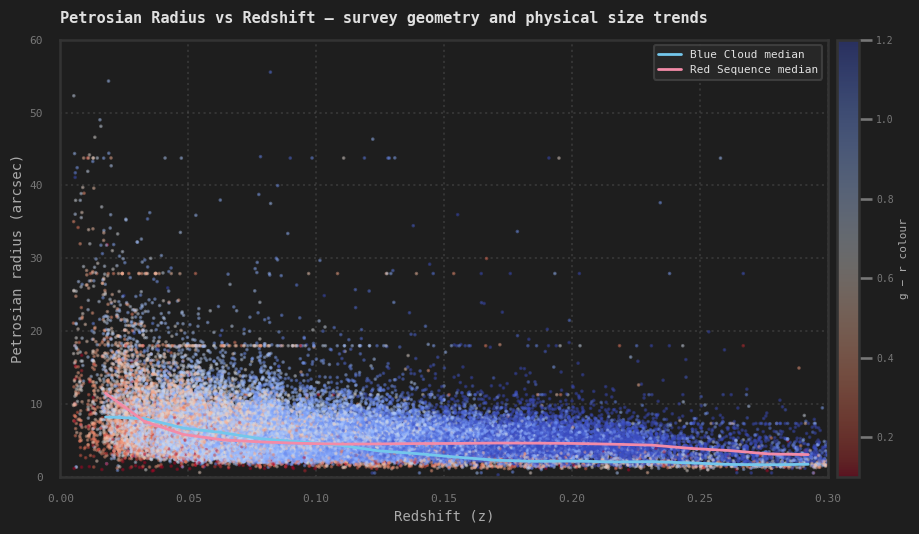

In [7]:
sample_z = galaxies[
    (galaxies["redshift"] > 0.005) &
    (galaxies["redshift"] < 0.30)  &
    (galaxies["petroRad_r"] < 60)
].sample(min(60000, len(galaxies)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 5.5), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

# Colour points by g-r, clipped to visible range
gr_clipped = sample_z["g_r"].clip(-0.1, 1.3)
sc = ax.scatter(
    sample_z["redshift"], sample_z["petroRad_r"],
    c=gr_clipped, cmap="coolwarm_r",
    vmin=0.1, vmax=1.2,
    s=1.2, alpha=0.4, rasterized=True
)

# Overlay median trend lines per colour class
z_bins = np.linspace(0.01, 0.30, 20)
z_mids = 0.5 * (z_bins[:-1] + z_bins[1:])

for subset, color, label in [
    (galaxies[(galaxies["redshift"] < 0.30) & (galaxies["g_r"] < 0.58)],
     "#74c7ec", "Blue Cloud median"),
    (galaxies[(galaxies["redshift"] < 0.30) & (galaxies["g_r"] > 0.76)],
     "#f38ba8", "Red Sequence median"),
]:
    medians = []
    for lo, hi in zip(z_bins[:-1], z_bins[1:]):
        bin_data = subset[
            (subset["redshift"] >= lo) &
            (subset["redshift"] <  hi) &
            (subset["petroRad_r"] < 60)
        ]["petroRad_r"]
        medians.append(np.median(bin_data) if len(bin_data) > 10 else np.nan)
    ax.plot(z_mids, medians, color=color, lw=2, label=label, zorder=5)

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("g − r colour", color="#aaaaaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar.outline.set_edgecolor("#333333")

ax.set_xlabel("Redshift (z)", color="#aaaaaa", fontsize=10)
ax.set_ylabel("Petrosian radius (arcsec)", color="#aaaaaa", fontsize=10)
ax.set_title("Petrosian Radius vs Redshift — survey geometry and physical size trends",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.set_xlim(0, 0.30)
ax.set_ylim(0, 60)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.10, color="#ffffff")
ax.legend(facecolor="#2a2a2a", edgecolor="#444444",
          labelcolor="#e0e0e0", fontsize=8, loc="upper right")
for spine in ax.spines.values(): spine.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

Three features of this plot are worth unpacking:

**The upper envelope drops with redshift.** At low $z$, we see galaxies spanning a wide range of apparent sizes — from tiny compact objects to large extended ones. At higher $z$, the largest apparent sizes disappear. This is partly geometric (physically large galaxies subtend smaller angles at larger distances) and partly the flux limit biting in (only the most luminous, often smaller, galaxies are detectable at high $z$).

**The lower envelope stays roughly flat.** The smallest apparent sizes we detect stay roughly constant with redshift. This reflects the seeing limit of the telescope — galaxies smaller than roughly 1–2 arcseconds cannot be well-resolved and are excluded by the Petrosian algorithm.

**Red galaxies are systematically smaller in apparent size than blue ones** at the same redshift (visible in the median trend lines). This is a real physical effect: elliptical galaxies tend to be more physically compact than spiral galaxies of comparable luminosity. Red sequence galaxies have concentrated their stellar mass into smaller volumes — consistent with the higher concentration indices we saw in Plot 1.

</div>

---

### Bonus Plot — The de Vaucouleurs Fraction: Disc vs Bulge

---

<div style="width: 1200px">

The column `fracDeV_r` gives us something complementary to the concentration index: a direct measure of how bulge-like vs disc-like the galaxy's light profile is, as determined by fitting two standard profile shapes to each object.

A value of `1.0` means the light is best described by a de Vaucouleurs ($n=4$) profile — compact, centrally concentrated, elliptical-like. A value of `0.0` means the light follows an exponential ($n=1$) disc profile. Values in between represent mixed systems.

Critically, `fracDeV_r` is determined from the *shape* of the light profile rather than just its spatial extent, making it an independent morphological measurement from $C$. Plotting the two against each other — coloured by $g-r$ — tests whether they agree.

</div>

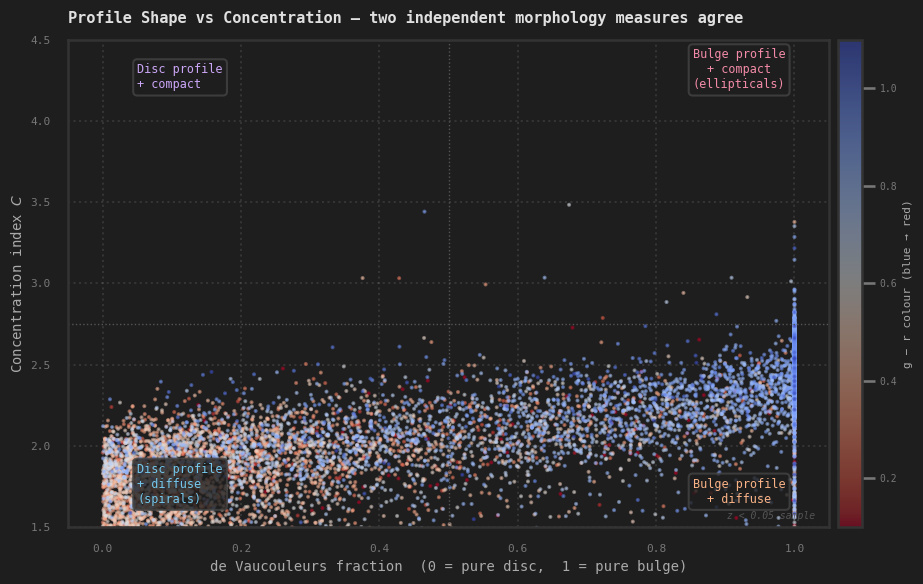

In [8]:
sample_fdev = gal_lowz[
    (gal_lowz["fracDeV_r"] >= 0) &
    (gal_lowz["fracDeV_r"] <= 1)
].sample(min(25000, len(gal_lowz)), random_state=42)

x = sample_fdev["fracDeV_r"].values
y = sample_fdev["C"].values
c = sample_fdev["g_r"].clip(0.0, 1.2).values

# Sort by g-r so blue points don't hide under red
sort_idx = np.argsort(c)
x, y, c = x[sort_idx], y[sort_idx], c[sort_idx]

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#1e1e1e")
ax.set_facecolor("#1e1e1e")

sc = ax.scatter(x, y, c=c, cmap="coolwarm_r", vmin=0.1, vmax=1.1,
                s=2, alpha=0.5, rasterized=True)

# Annotate the corners
corner_props = dict(
    fontsize=8.5, bbox=dict(boxstyle="round,pad=0.35",
                            fc="#1e1e1e", ec="#444444", alpha=0.8)
)
ax.text(0.05, 4.2, "Disc profile\n+ compact",
        color="#cba6f7", ha="left", **corner_props)
ax.text(0.92, 4.2, "Bulge profile\n+ compact\n(ellipticals)",
        color="#f38ba8", ha="center", **corner_props)
ax.text(0.05, 1.65, "Disc profile\n+ diffuse\n(spirals)",
        color="#74c7ec", ha="left", **corner_props)
ax.text(0.92, 1.65, "Bulge profile\n+ diffuse",
        color="#fab387", ha="center", **corner_props)

ax.axvline(0.5, color="#555555", lw=1, linestyle=":")
ax.axhline(2.75, color="#555555", lw=1, linestyle=":")

cbar = plt.colorbar(sc, ax=ax, pad=0.01)
cbar.set_label("g − r colour (blue → red)", color="#aaaaaa", fontsize=8)
cbar.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#777777", fontsize=7)
cbar.outline.set_edgecolor("#333333")

ax.set_xlabel("de Vaucouleurs fraction  (0 = pure disc,  1 = pure bulge)",
              color="#aaaaaa", fontsize=10)
ax.set_ylabel(r"Concentration index $C$", color="#aaaaaa", fontsize=10)
ax.set_title("Profile Shape vs Concentration — two independent morphology measures agree",
             color="#e0e0e0", fontsize=11, loc="left", pad=12)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(1.5, 4.5)
ax.tick_params(colors="#777777", labelsize=8)
ax.grid(True, linestyle=":", alpha=0.10, color="#ffffff")
for spine in ax.spines.values(): spine.set_edgecolor("#333333")
ax.text(1.03, 1.55, "z < 0.05 sample",
        color="#555555", fontsize=7, ha="right", style="italic")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

The two morphological measurements agree remarkably well. Galaxies with high `fracDeV_r` (bulge-like profiles) also tend to have high $C$ (centrally concentrated light), and they are coloured red. Galaxies with low `fracDeV_r` (disc-like profiles) tend to have low $C$ and are coloured blue.

This agreement is reassuring — it tells us that the morphological signal we're measuring is robust. The `fracDeV_r` parameter is derived from profile *shape* fitting, while $C$ is derived purely from the radii enclosing fixed light fractions. They are computed in completely different ways, yet they point to the same physical picture.

Notice also that `fracDeV_r` shows a **bimodal distribution** — galaxies tend to cluster near `0` or near `1`, with fewer in the intermediate range. This mirrors the colour bimodality we saw in Part 2, and reinforces the idea that galaxy morphology, like colour, is not a smooth continuum but a bimodal distribution driven by distinct evolutionary pathways.

</div>

---

### What We've Learned

---


<div style="width: 1200px">

Structure and colour tell a consistent story — but with important nuance.

The main findings from this notebook:

* **The Hubble Tuning Fork organises galaxy morphology** into a sequence from ellipticals (red, concentrated, quenched) to spirals (blue, diffuse, star-forming) — and our SDSS measurements reproduce this gradient quantitatively.

* **Colour and morphology are correlated but not identical.** Blue galaxies tend to be disc-dominated spirals; red galaxies tend to be bulge-dominated ellipticals. But the off-diagonal quadrants — passive discs and compact star-formers — tell us that quenching and structural transformation are not always the same process.

* **The concentration index $C$ is a powerful single-number morphological classifier.** It cleanly separates the blue and red populations in our sample, with green valley galaxies spanning both, consistent with a structural transformation happening alongside (or after) quenching.

* **The Petrosian radius reveals survey geometry.** The apparent size vs redshift plot is not just a data quality diagnostic — it encodes real physics. Red galaxies are systematically more compact than blue ones at the same redshift, a direct consequence of their different formation histories.

* **The de Vaucouleurs fraction independently confirms the morphological picture.** Two different ways of measuring structure — profile shape and concentration — agree with each other and with colour. The physical signal is real.

In the next notebook, we move from structure to **distance** — using redshift and luminosity to place our galaxies in space and time, and beginning to trace how galaxy properties have evolved across cosmic history.

</div>